# Channel Response Experient

This compares radio propogation beteween transmitter / receiver. 

In [62]:
import numpy as np
import sionna.rt as rt

from sionna.rt import (
    ITURadioMaterial,
    PathSolver,
    PlanarArray,
    Receiver,
    Transmitter,
    load_scene,
)

CARRIER_FREQUENCY = 2.4e9
SOLVER_SEED = 41

The scene uses Sionna RT's built in simple reflector scene. A transmitter / reciever are placed 4 memters apart with an antenna at each endpoint. 

Carrier frequency = 2.4 GHz

In [63]:
scene = load_scene(
    rt.scene.simple_reflector,
    merge_shapes=False,
)

scene.frequency = CARRIER_FREQUENCY
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    pattern="iso",
    polarization="V",
)

scene.rx_array = scene.tx_array

tx = Transmitter(
    name="tx",
    position=[-2.0, 0.0, 1.0],
)

rx = Receiver(
    name="rx",
    position=[2.0, 0.0, 1.0],
)

scene.add(tx)
scene.add(rx)
tx.look_at(rx)

In [64]:
path_solver = PathSolver()


def extract_channel_response(paths):
    coefficients, delays = paths.cir(
        normalize_delays=False,
        out_type="numpy",
    )
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    coefficients = np.asarray(coefficients)[0, 0, 0, 0, :, 0]
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    delays = np.asarray(delays)[0, 0, 0, 0, :]

    order = np.argsort(delays)
    return coefficients[order], delays[order]

The first simulation uses max depth of 0, so only the direct line of sight path is considered.

In [65]:
paths_los = path_solver(
    scene=scene,
    max_depth=0,
    los=True,
    specular_reflection=False,
    diffuse_reflection=False,
    refraction=False,
    synthetic_array=False,
    seed=SOLVER_SEED,
)

los_response = extract_channel_response(paths_los)
print("Direct-path delay [ns]:", los_response[1] * 1e9)
print("Direct-path amplitude:", np.abs(los_response[0]))
print("Direct-path phase [rad]:", np.angle(los_response[0]))

Direct-path delay [ns]: [13.342564]
Direct-path amplitude: [0.00248508]
Direct-path phase [rad]: [-0.1391905]


Built in reflector is assigned the ITU medium_dry_ground radio material

Max depth of 1 allows for direct path, and paths that reflect once

In [66]:
soil_material = ITURadioMaterial(
    name="medium-dry-ground",
    itu_type="medium_dry_ground",
    thickness=0.10,
)

scene.add(soil_material)
scene.objects["reflector"].radio_material = soil_material.name

paths_material = path_solver(
    scene=scene,
    max_depth=1,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=True,
    synthetic_array=False,
    seed=SOLVER_SEED,
)

material_response = extract_channel_response(paths_material)
print("Material-case delay [ns]:", material_response[1] * 1e9)
print("Material-case amplitude:", np.abs(material_response[0]))
print("Material-case phase [rad]:", np.angle(material_response[0]))

Material-case delay [ns]: [13.342564 14.917439]
Material-case amplitude: [0.00248508 0.00058781]
Material-case phase [rad]: [-0.1391905   0.97610575]


In [67]:
channelResponse = {
    "direct": los_response,
    "medium_dry_ground": material_response,
}

for case_name, response in channelResponse.items():
    coefficients, delays = response
    print(case_name)
    for coefficient, delay in zip(coefficients, delays):
        print(
            f"delay={delay * 1e9:.3f} ns, "
            f"amplitude={abs(coefficient):.6f}, "
            f"phase={np.angle(coefficient):.6f} rad"
        )

direct
delay=13.343 ns, amplitude=0.002485, phase=-0.139190 rad
medium_dry_ground
delay=13.343 ns, amplitude=0.002485, phase=-0.139190 rad
delay=14.917 ns, amplitude=0.000588, phase=0.976106 rad


- Direct path case produced one path at ~13.343 ns
- Material case produced the same direct path, along with a weaker reflected path at ~14.917 ns

rendering

In [68]:
from pathlib import Path
from sionna.rt import Camera

camera = Camera(
    position=[0.0, -6.0, 3.0],
    look_at=[0.0, 0.0, 1.0],
)

output_path = Path(
    r"C:\Users\jaspe\OneDrive\Documents\sionna-rf-simulation"
) / "results" / "figures" / "simple_reflector_paths.png"

scene.render_to_file(
    camera=camera,
    filename=str(output_path),
    paths=paths_material,
    resolution=[800, 600],
    num_samples=128,
)

print(f"Saved to: {output_path}")

Saved to: C:\Users\jaspe\OneDrive\Documents\sionna-rf-simulation\results\figures\simple_reflector_paths.png


## Channel response plots

The direct-path case contains one line-of-sight path. The reflector case retains that path and adds a weaker reflected path with a longer delay.

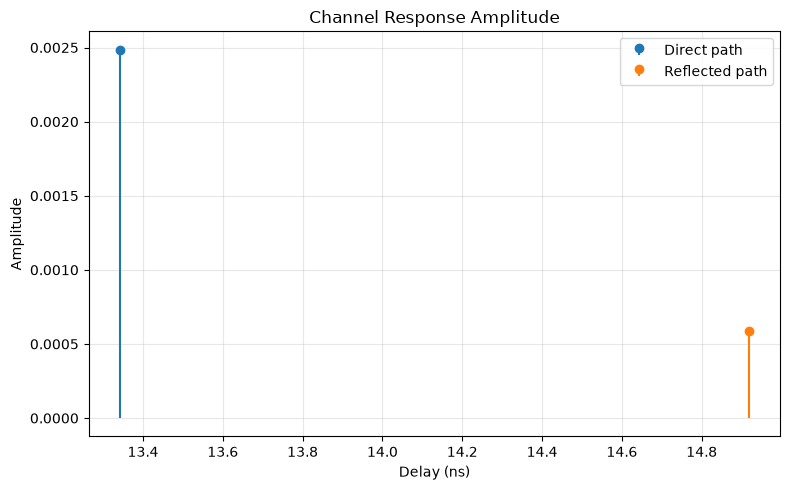

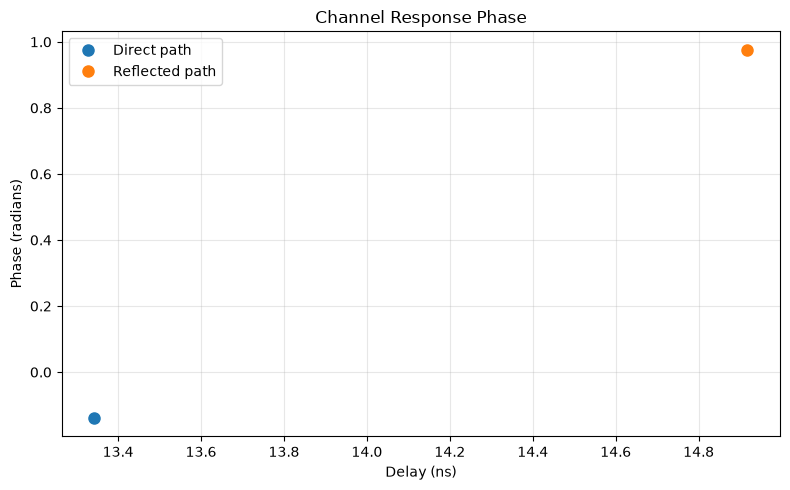

In [69]:
from pathlib import Path
import matplotlib.pyplot as plt

figure_dir = Path(
    r"C:\Users\jaspe\OneDrive\Documents\sionna-rf-simulation"
) / "results" / "figures"

figure_dir.mkdir(parents=True, exist_ok=True)

material_coefficients, material_delays = material_response

reflector_direct_coefficients = material_coefficients[:1]
reflector_direct_delays = material_delays[:1]

reflected_coefficients = material_coefficients[1:]
reflected_delays = material_delays[1:]

# Reflector-case amplitude plot
fig, axis = plt.subplots(figsize=(8, 5))

axis.stem(
    reflector_direct_delays * 1e9,
    np.abs(reflector_direct_coefficients),
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" ",
    label="Direct path",
)
axis.stem(
    reflected_delays * 1e9,
    np.abs(reflected_coefficients),
    linefmt="C1-",
    markerfmt="C1o",
    basefmt=" ",
    label="Reflected path",
)
axis.set_xlabel("Delay (ns)")
axis.set_ylabel("Amplitude")
axis.set_title("Channel Response Amplitude")
axis.legend()
axis.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figure_dir / "channel_response_amplitude.png", dpi=150)

plt.show()
plt.close(fig)


# Reflector-case phase plot
fig, axis = plt.subplots(figsize=(8, 5))

axis.plot(
    reflector_direct_delays * 1e9,
    np.angle(reflector_direct_coefficients),
    "o",
    color="C0",
    markersize=8,
    label="Direct path",
)
axis.plot(
    reflected_delays * 1e9,
    np.angle(reflected_coefficients),
    "o",
    color="C1",
    markersize=8,
    label="Reflected path",
)
axis.set_xlabel("Delay (ns)")
axis.set_ylabel("Phase (radians)")
axis.set_title("Channel Response Phase")
axis.legend()
axis.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figure_dir / "channel_response_phase.png", dpi=150)

plt.show()
plt.close(fig)